<a href="https://colab.research.google.com/github/roshnidbth/Hybrid-Churn-Prediction-System/blob/main/Data_preprocessing_and_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install any missing libraries (Colab usually has these)
# !pip install scikit-learn pandas matplotlib seaborn xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

# --- Supervised Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)

# ── NEW: XGBoost ──────────────────────────────────────────────────
from xgboost import XGBClassifier

# --- Unsupervised Learning ---
from sklearn.cluster import KMeans, DBSCAN                  # NEW: DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors  # NEW

sns.set_style('whitegrid')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"

Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 12.07 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.


In [3]:
# Auto-find the Telco Churn CSV anywhere in the cloned folder
matches = glob.glob('/content/Datasets/**/*Telco*Churn*.csv', recursive=True)
if not matches:
    matches = glob.glob('/content/Datasets/**/*.csv', recursive=True)

print('Found files:', matches)
csv_path = matches[0]
print(f'Using: {csv_path}')

df = pd.read_csv(csv_path)
print('\n✅ Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Found files: ['/content/Datasets/Customer Churn Dataset/Telco-Customer-Churn.csv']
Using: /content/Datasets/Customer Churn Dataset/Telco-Customer-Churn.csv

✅ Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(f'Shape before cleaning: {df.shape}')

# Fix TotalCharges: convert to numeric, coerce spaces/blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Missing TotalCharges: {df["TotalCharges"].isnull().sum()}')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.dropna(subset=['Churn'], inplace=True)

# Drop non-informative ID column
df.drop('customerID', axis=1, inplace=True)

print(f'Shape after cleaning: {df.shape}')
print('\n✅ Data cleaning complete!')
df.info()

Shape before cleaning: (7043, 21)
Missing TotalCharges: 11
Shape after cleaning: (7043, 20)

✅ Data cleaning complete!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract         

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


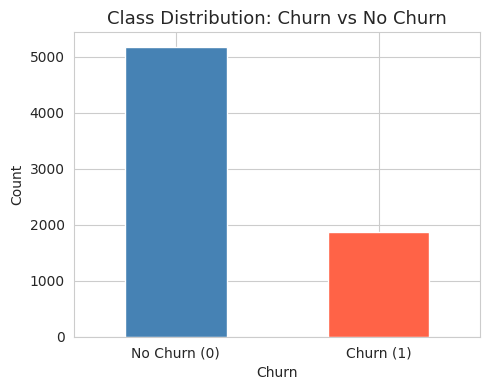

In [5]:
# Check class balance
print('Churn distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
df['Churn'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution: Churn vs No Churn', fontsize=13)
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
# Define features (X) and target (y)
X_base = df.drop('Churn', axis=1)
y_base = df['Churn']

# Identify feature types
numerical_features_base = X_base.select_dtypes(include=np.number).columns.tolist()
categorical_features_base = X_base.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features ({len(numerical_features_base)}): {numerical_features_base}')
print(f'Categorical features ({len(categorical_features_base)}): {categorical_features_base}')

# Preprocessing pipeline
preprocessor_base = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features_base),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_base)
])

# Train/test split
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)

# Full pipeline with classifier
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor_base),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

baseline_model.fit(X_train_base, y_train_base)
y_pred_base = baseline_model.predict(X_test_base)

print('\n--- Baseline Model Performance ---')
print(classification_report(y_test_base, y_pred_base))

Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

--- Baseline Model Performance ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [7]:
df_eng = df.copy()

# 1. Bin tenure into lifecycle groups
bins = [0, 12, 24, 48, 60, 72]
labels = ['0-1 Year', '1-2 Years', '2-4 Years', '4-5 Years', '5+ Years']
df_eng['tenure_group'] = pd.cut(df_eng['tenure'], bins=bins, labels=labels, right=False)

# 2. Simplify multi-value categoricals
df_eng['MultipleLines'] = df_eng['MultipleLines'].replace({'No phone service': 'No'})
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df_eng[col] = df_eng[col].replace({'No internet service': 'No'})

# 3. Count total add-on services
df_eng['num_add_services'] = (
    df_eng[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']] == 'Yes'
).sum(axis=1)

# 4. Monthly charge relative to tenure (+1 to avoid division by zero)
df_eng['monthly_charge_ratio'] = df_eng['MonthlyCharges'] / (df_eng['tenure'] + 1)

# 5. Drop original tenure (replaced by binned version)
df_eng.drop('tenure', axis=1, inplace=True)

print('✅ Feature engineering complete!')
print(f'New shape: {df_eng.shape}')
print(f'New features added: tenure_group, num_add_services, monthly_charge_ratio')
df_eng.head()

✅ Feature engineering complete!
New shape: (7043, 22)
New features added: tenure_group, num_add_services, monthly_charge_ratio


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_add_services,monthly_charge_ratio
0,Female,0,Yes,No,No,No,DSL,No,Yes,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,1,14.925000
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,2-4 Years,2,1.627143
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,2,17.950000
3,Male,0,No,No,No,No,DSL,Yes,No,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4 Years,3,0.919565
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,0,23.566667


In [8]:
X_eng = df_eng.drop('Churn', axis=1)
y_eng = df_eng['Churn']

numerical_features_eng = X_eng.select_dtypes(include=np.number).columns.tolist()
categorical_features_eng = X_eng.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numerical features ({len(numerical_features_eng)}): {numerical_features_eng}')
print(f'Categorical features ({len(categorical_features_eng)}): {categorical_features_eng}')

preprocessor_eng = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features_eng),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_eng)
])

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

enhanced_model = Pipeline(steps=[
    ('preprocessor', preprocessor_eng),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

enhanced_model.fit(X_train_eng, y_train_eng)
y_pred_eng = enhanced_model.predict(X_test_eng)

print('\n--- Enhanced Model Performance (with Feature Engineering) ---')
print(classification_report(y_test_eng, y_pred_eng))

Numerical features (5): ['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'num_add_services', 'monthly_charge_ratio']
Categorical features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

--- Enhanced Model Performance (with Feature Engineering) ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



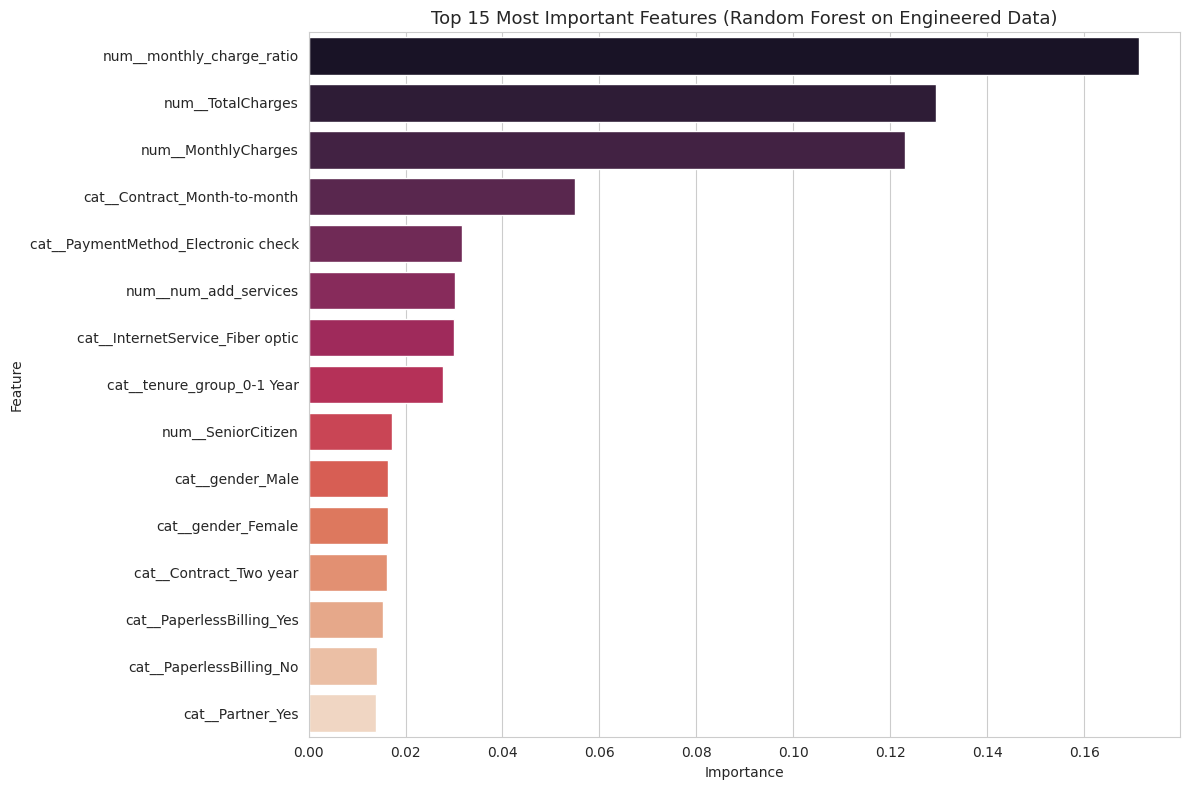

In [9]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_eng),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])
rf_pipeline.fit(X_train_eng, y_train_eng)
y_pred_rf = rf_pipeline.predict(X_test_eng)

print('--- Random Forest Performance ---')
print(classification_report(y_test_eng, y_pred_rf))

# Extract feature importances
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', y='Feature', data=feature_importance_df,
    palette='rocket', hue='Feature', legend=False
)
plt.title('Top 15 Most Important Features (Random Forest on Engineered Data)', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
rf_selector = RandomForestClassifier(random_state=42)
selector = SelectFromModel(estimator=rf_selector, threshold='median', prefit=False)

# Build a pipeline for feature selection only (to check dimensionality)
selection_check_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_eng),
    ('selector', selector)
])
selection_check_pipeline.fit(X_train_eng, y_train_eng)

X_train_selected = selection_check_pipeline.transform(X_train_eng)
X_test_selected = selection_check_pipeline.transform(X_test_eng)

print(f'Original training feature count : {X_train_eng.shape[1]}')
print(f'Selected training feature count : {X_train_selected.shape[1]}')
print(f'Features reduced by             : {X_train_eng.shape[1] - X_train_selected.shape[1]}')

Original training feature count : 21
Selected training feature count : 23
Features reduced by             : -2


In [11]:
# Train Logistic Regression on the full engineered set (SelectFromModel handles pruning internally)
selected_features_model = Pipeline(steps=[
    ('preprocessor', preprocessor_eng),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])
selected_features_model.fit(X_train_eng, y_train_eng)
y_pred_selected = selected_features_model.predict(X_test_eng)

print('--- Model Performance (Selected Features) ---')
print(classification_report(y_test_eng, y_pred_selected))

--- Model Performance (Selected Features) ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



         SUPERVISED MODEL COMPARISON SUMMARY
Model                  Accuracy     F1 (Churn=1)   
------------------------------------------------------------
Baseline (LR)          0.8055       0.6040         
Enhanced (LR)          0.8048       0.5840         
Random Forest          0.7828       0.5433         
Selected (LR)          0.8048       0.5840         


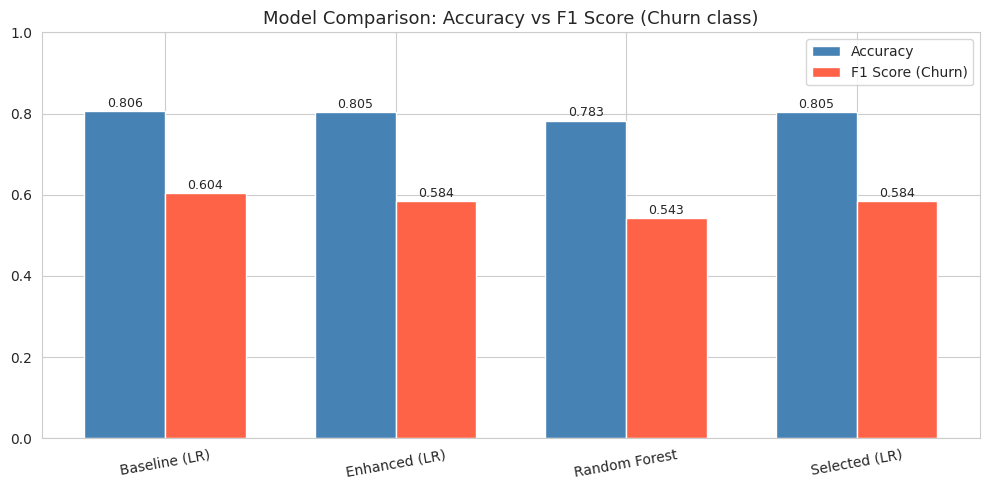

In [12]:
report_base = classification_report(y_test_base, y_pred_base, output_dict=True)
report_eng = classification_report(y_test_eng, y_pred_eng, output_dict=True)
report_rf = classification_report(y_test_eng, y_pred_rf, output_dict=True)
report_sel = classification_report(y_test_eng, y_pred_selected, output_dict=True)

models = ['Baseline (LR)', 'Enhanced (LR)', 'Random Forest', 'Selected (LR)']
accuracies = [
    accuracy_score(y_test_base, y_pred_base),
    accuracy_score(y_test_eng, y_pred_eng),
    accuracy_score(y_test_eng, y_pred_rf),
    accuracy_score(y_test_eng, y_pred_selected)
]
f1_churn = [
    report_base['1']['f1-score'],
    report_eng['1']['f1-score'],
    report_rf['1']['f1-score'],
    report_sel['1']['f1-score']
]

# Print table
print('=' * 60)
print('         SUPERVISED MODEL COMPARISON SUMMARY')
print('=' * 60)
print(f'{"Model":<22} {"Accuracy":<12} {"F1 (Churn=1)":<15}')
print('-' * 60)
for m, acc, f1 in zip(models, accuracies, f1_churn):
    print(f'{m:<22} {acc:<12.4f} {f1:<15.4f}')
print('=' * 60)

# Plot
x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_churn, width, label='F1 Score (Churn)', color='tomato')
ax.set_title('Model Comparison: Accuracy vs F1 Score (Churn class)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=10)
ax.set_ylim(0, 1)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 🆕 Upgrade — XGBoost + ROC-AUC Suite + Confusion Matrix
This section adds XGBoost to the existing Logistic Regression and Random Forest.
All three models are evaluated with ROC-AUC curves and a confusion matrix for the best performer.

--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


🏆  Best Supervised Model (by F1): Logistic Regression

     SUPERVISED MODEL COMPARISON SUMMARY (UPGRADED)
Model                    Accuracy   F1 Score    ROC AUC
-------------------------------------------------------
Logistic Regression        0.8048     0.5840     0.8433 ◄ BEST
Random Forest              0.7828     0.5433     0.8201
XGBoost                    0.7928     0.5731     0.8367


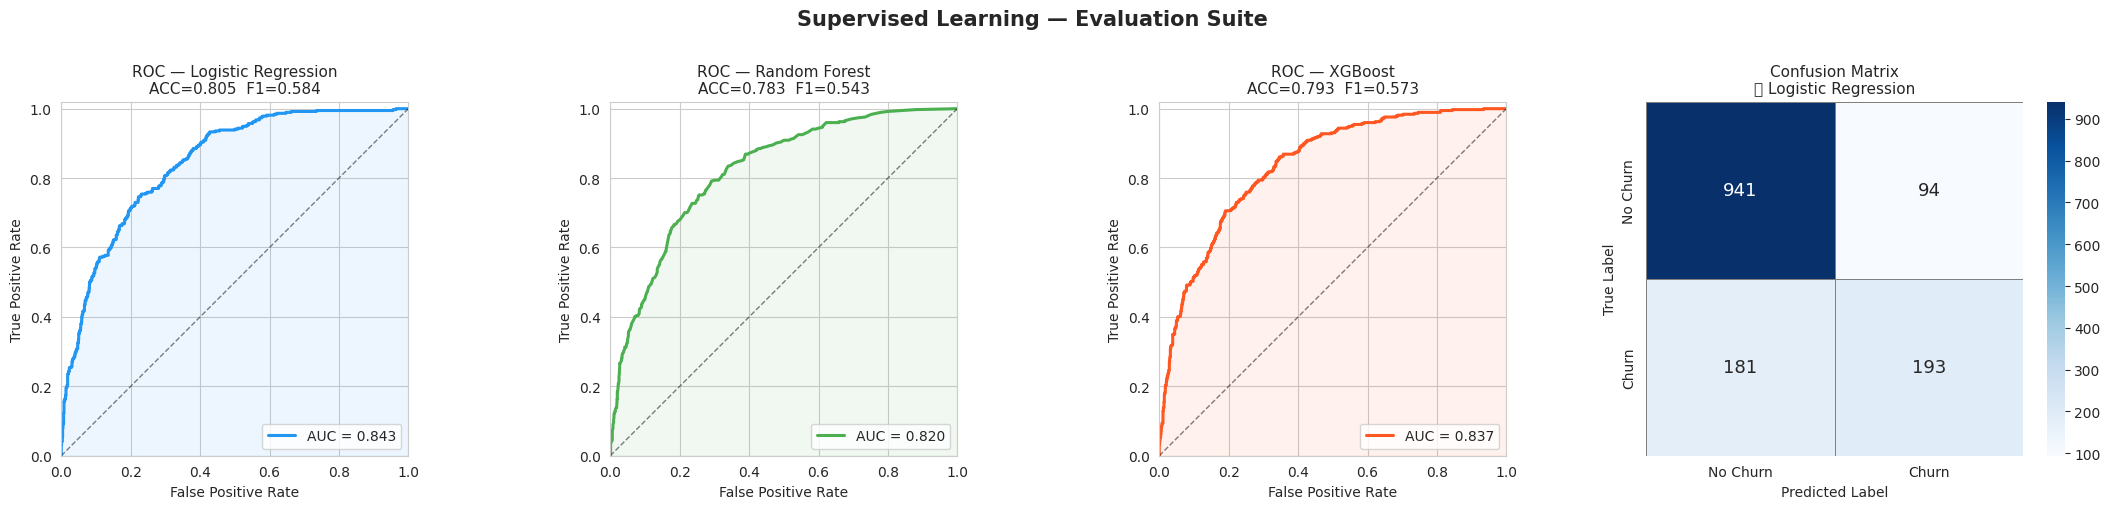

✅ Supervised evaluation suite complete!


In [13]:
# ── 2a. Train XGBoost ─────────────────────────────────────────────
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_eng),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])
xgb_pipeline.fit(X_train_eng, y_train_eng)
y_pred_xgb  = xgb_pipeline.predict(X_test_eng)
y_proba_xgb = xgb_pipeline.predict_proba(X_test_eng)[:, 1]

print('--- XGBoost Performance ---')
print(classification_report(y_test_eng, y_pred_xgb))


# ── 2b. Collect all three models for comparison ───────────────────
# (lr = enhanced_model, rf = rf_pipeline from the existing notebook)
supervised_models = {
    'Logistic Regression': {
        'pipeline'  : enhanced_model,
        'y_pred'    : y_pred_eng,
        'y_proba'   : enhanced_model.predict_proba(X_test_eng)[:, 1],
    },
    'Random Forest': {
        'pipeline'  : rf_pipeline,
        'y_pred'    : y_pred_rf,
        'y_proba'   : rf_pipeline.predict_proba(X_test_eng)[:, 1],
    },
    'XGBoost': {
        'pipeline'  : xgb_pipeline,
        'y_pred'    : y_pred_xgb,
        'y_proba'   : y_proba_xgb,
    },
}


# ── 2c. Compute metrics for all three ────────────────────────────
results_supervised = {}
for name, info in supervised_models.items():
    acc = accuracy_score(y_test_eng, info['y_pred'])
    f1  = f1_score(y_test_eng, info['y_pred'])
    fpr, tpr, _ = roc_curve(y_test_eng, info['y_proba'])
    roc_auc = auc(fpr, tpr)
    results_supervised[name] = {
        'Accuracy'  : acc,
        'F1 Score'  : f1,
        'ROC AUC'   : roc_auc,
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_pred'    : info['y_pred'],
    }

# Determine best model by F1 Score (tie-break: Accuracy)
best_model_name = max(
    results_supervised,
    key=lambda n: (results_supervised[n]['F1 Score'],
                   results_supervised[n]['Accuracy'])
)
print(f'\n🏆  Best Supervised Model (by F1): {best_model_name}')


# ── 2d. Print comparison table ────────────────────────────────────
print('\n' + '=' * 55)
print('     SUPERVISED MODEL COMPARISON SUMMARY (UPGRADED)')
print('=' * 55)
print(f'{"Model":<22} {"Accuracy":>10} {"F1 Score":>10} {"ROC AUC":>10}')
print('-' * 55)
for name, r in results_supervised.items():
    marker = ' ◄ BEST' if name == best_model_name else ''
    print(f'{name:<22} {r["Accuracy"]:>10.4f} {r["F1 Score"]:>10.4f} '
          f'{r["ROC AUC"]:>10.4f}{marker}')
print('=' * 55)


# ── 2e. Visualization: ROC curves (3-panel) + best-model CM ──────
palette = {
    'Logistic Regression' : '#2196F3',
    'Random Forest'       : '#4CAF50',
    'XGBoost'             : '#FF5722',
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Supervised Learning — Evaluation Suite', fontsize=15, fontweight='bold', y=1.01)

for i, (name, r) in enumerate(results_supervised.items()):
    ax = axes[i]
    ax.plot(r['fpr'], r['tpr'],
            color=palette[name], lw=2.2,
            label=f'AUC = {r["ROC AUC"]:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(r['fpr'], r['tpr'], alpha=0.08, color=palette[name])
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'ROC — {name}\nACC={r["Accuracy"]:.3f}  F1={r["F1 Score"]:.3f}',
                 fontsize=11)
    ax.legend(loc='lower right', fontsize=10)
    ax.set_aspect('equal')

# Confusion matrix for best model
ax_cm = axes[3]
cm = confusion_matrix(y_test_eng, results_supervised[best_model_name]['y_pred'])
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
    linewidths=0.5, linecolor='grey',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    annot_kws={'size': 13}
)
ax_cm.set_title(f'Confusion Matrix\n🏆 {best_model_name}', fontsize=11)
ax_cm.set_xlabel('Predicted Label', fontsize=10)
ax_cm.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('supervised_evaluation_suite.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Supervised evaluation suite complete!')

In [14]:
df_cluster = df_eng.copy()

# Label encode all categorical columns for clustering
le = LabelEncoder()
for col in df_cluster.select_dtypes(include=['object', 'category']).columns:
    df_cluster[col] = le.fit_transform(df_cluster[col].astype(str))

# Separate features and true labels
X_clust = df_cluster.drop('Churn', axis=1)
y_true = df_cluster['Churn']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print('✅ Encoding & scaling complete!')
print(f'Feature matrix shape: {X_scaled.shape}')

✅ Encoding & scaling complete!
Feature matrix shape: (7043, 21)


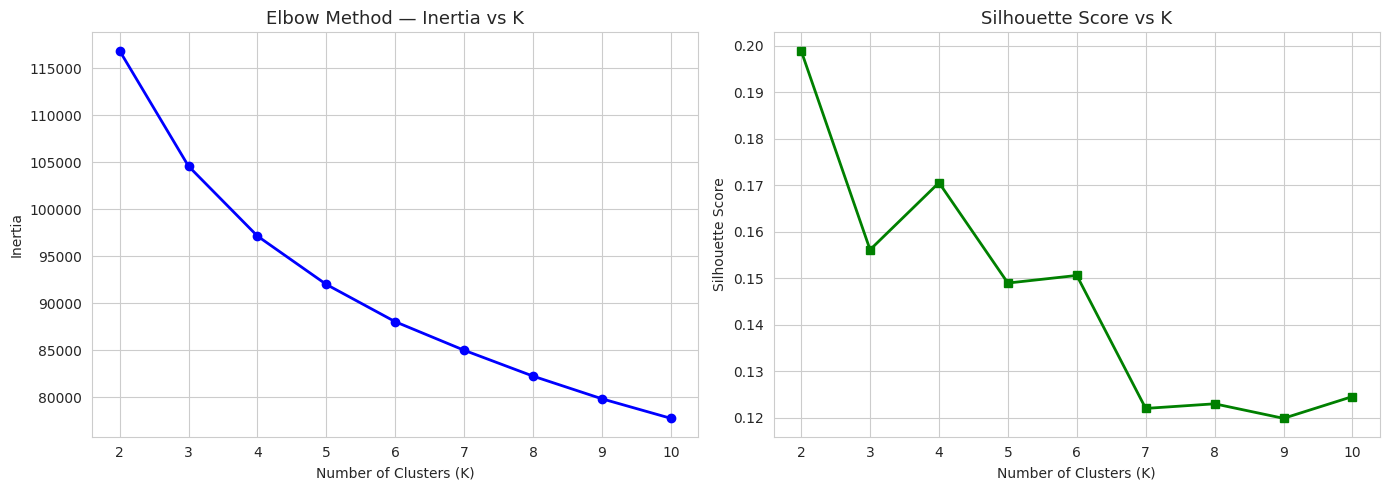


✅ Best K by Silhouette Score: 2


In [15]:
inertia_list = []
silhouette_list = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels_km))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_list, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_list, 'gs-', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouette_list)]
print(f'\n✅ Best K by Silhouette Score: {best_k}')

In [16]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_eng['KMeans_Cluster'] = kmeans_labels

sil_km = silhouette_score(X_scaled, kmeans_labels)
ari_km = adjusted_rand_score(y_true, kmeans_labels)

print(f'✅ K-Means Results (K={best_k})')
print(f'   Silhouette Score    : {sil_km:.4f}')
print(f'   Adjusted Rand Index : {ari_km:.4f}')
print(f'\nCluster Distribution:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

✅ K-Means Results (K=2)
   Silhouette Score    : 0.1989
   Adjusted Rand Index : -0.0064

Cluster Distribution:
0    4167
1    2876
Name: count, dtype: int64


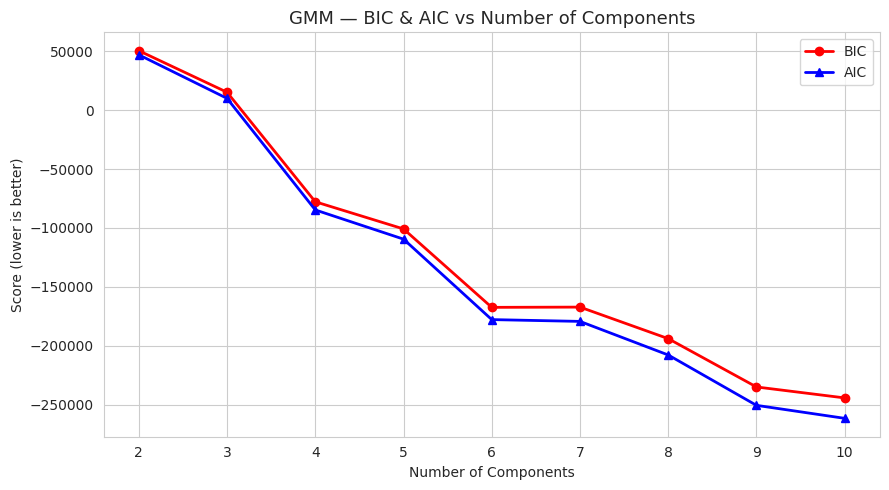


✅ Best GMM components by BIC: 10


In [17]:
bic_scores = []
aic_scores = []
n_range = range(2, 11)

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=5)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_range, bic_scores, 'ro-', label='BIC', linewidth=2)
ax.plot(n_range, aic_scores, 'b^-', label='AIC', linewidth=2)
ax.set_title('GMM — BIC & AIC vs Number of Components', fontsize=13)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Score (lower is better)')
ax.legend()
plt.tight_layout()
plt.show()

best_n_gmm = list(n_range)[np.argmin(bic_scores)]
print(f'\n✅ Best GMM components by BIC: {best_n_gmm}')

In [18]:
gmm_final = GaussianMixture(n_components=best_n_gmm, random_state=42, n_init=5)
gmm_labels = gmm_final.fit_predict(X_scaled)

df_eng['GMM_Cluster'] = gmm_labels

sil_gmm = silhouette_score(X_scaled, gmm_labels)
ari_gmm = adjusted_rand_score(y_true, gmm_labels)

print(f'✅ GMM Results (components={best_n_gmm})')
print(f'   Silhouette Score    : {sil_gmm:.4f}')
print(f'   Adjusted Rand Index : {ari_gmm:.4f}')
print(f'\nCluster Distribution:')
print(pd.Series(gmm_labels).value_counts().sort_index())

✅ GMM Results (components=10)
   Silhouette Score    : 0.0664
   Adjusted Rand Index : 0.0213

Cluster Distribution:
0     682
1     531
2    1114
3     545
4     593
5     825
6     798
7     760
8     555
9     640
Name: count, dtype: int64


Explained variance by 2 PCs: 40.4%


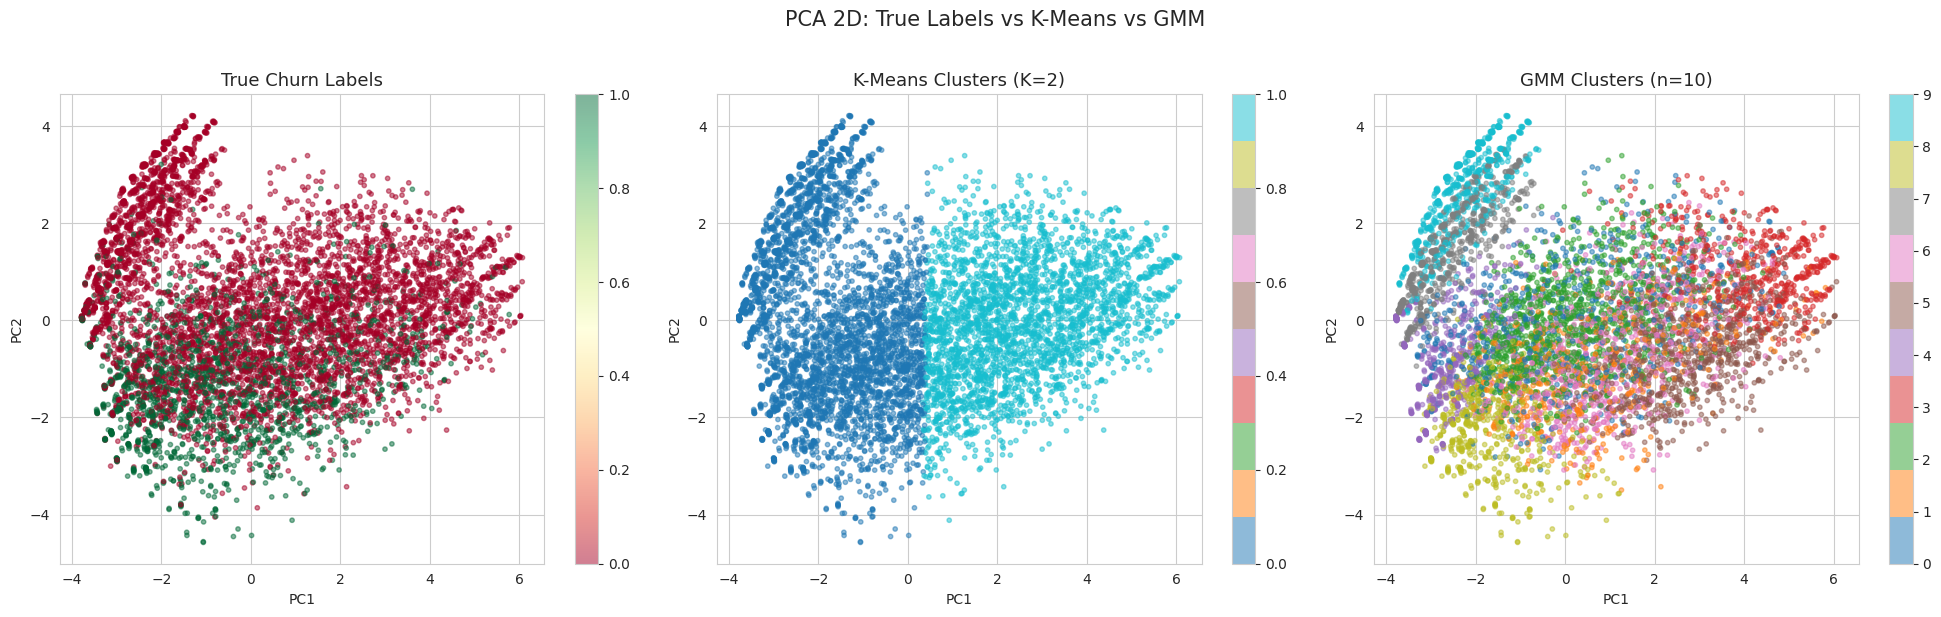

In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Explained variance by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='RdYlGn', alpha=0.5, s=10)
axes[0].set_title('True Churn Labels', fontsize=13)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.5, s=10)
axes[1].set_title(f'K-Means Clusters (K={best_k})', fontsize=13)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[1])

sc2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='tab10', alpha=0.5, s=10)
axes[2].set_title(f'GMM Clusters (n={best_n_gmm})', fontsize=13)
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[2])

plt.suptitle('PCA 2D: True Labels vs K-Means vs GMM', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

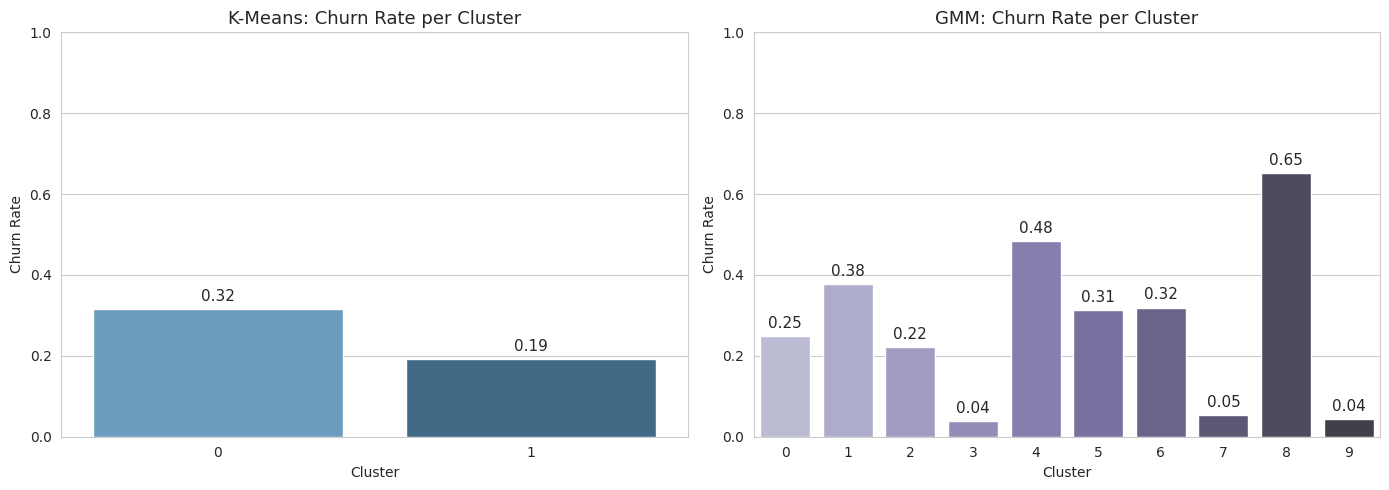

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means churn rate per cluster
km_churn = df_eng.groupby('KMeans_Cluster')['Churn'].mean().reset_index()
km_churn.columns = ['Cluster', 'Churn Rate']
sns.barplot(data=km_churn, x='Cluster', y='Churn Rate', palette='Blues_d', ax=axes[0])
axes[0].set_title('K-Means: Churn Rate per Cluster', fontsize=13)
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.02),
                     ha='center', fontsize=11)

# GMM churn rate per cluster
gmm_churn = df_eng.groupby('GMM_Cluster')['Churn'].mean().reset_index()
gmm_churn.columns = ['Cluster', 'Churn Rate']
sns.barplot(data=gmm_churn, x='Cluster', y='Churn Rate', palette='Purples_d', ax=axes[1])
axes[1].set_title('GMM: Churn Rate per Cluster', fontsize=13)
axes[1].set_ylim(0, 1)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.02),
                     ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
# Profile K-Means clusters by key numeric features
print('=== K-Means Cluster Profile (mean values) ===')
cluster_profile = df_eng.groupby('KMeans_Cluster')[[
    'MonthlyCharges', 'TotalCharges', 'num_add_services', 'monthly_charge_ratio', 'Churn'
]].mean().round(3)
cluster_profile.columns = ['Avg Monthly Charges', 'Avg Total Charges',
                            'Avg Add-on Services', 'Avg Charge Ratio', 'Churn Rate']
print(cluster_profile.to_string())

=== K-Means Cluster Profile (mean values) ===
                Avg Monthly Charges  Avg Total Charges  Avg Add-on Services  Avg Charge Ratio  Churn Rate
KMeans_Cluster                                                                                           
0                            49.087            828.636                0.768             8.063       0.316
1                            87.473           4387.557                3.878             2.450       0.192


In [22]:
print('=' * 55)
print('        CLUSTERING COMPARISON SUMMARY')
print('=' * 55)
print(f'{"Method":<20} {"Silhouette":<15} {"ARI vs Churn":<15}')
print('-' * 55)
print(f'{"K-Means":<20} {sil_km:<15.4f} {ari_km:<15.4f}')
print(f'{"GMM":<20} {sil_gmm:<15.4f} {ari_gmm:<15.4f}')
print('=' * 55)
print()
print('Interpretation Guide:')
print('  Silhouette Score → closer to 1.0 = better cluster separation')
print('  ARI              → closer to 1.0 = clusters align with true churn')
print()
print('✅ Full pipeline complete!')

        CLUSTERING COMPARISON SUMMARY
Method               Silhouette      ARI vs Churn   
-------------------------------------------------------
K-Means              0.1989          -0.0064        
GMM                  0.0664          0.0213         

Interpretation Guide:
  Silhouette Score → closer to 1.0 = better cluster separation
  ARI              → closer to 1.0 = clusters align with true churn

✅ Full pipeline complete!


## 🆕 Upgrade — DBSCAN with KNN Knee Auto-eps + 3-Panel PCA + Silhouette Bar Chart
This section adds DBSCAN (with automatic eps estimation) and a full 3-way clustering comparison.

──────────────────────────────────────────────────
  DBSCAN: Estimating optimal eps via KNN Knee Method
──────────────────────────────────────────────────
  → k used for KNN distance: 42
  → Knee index             : 5
  → Auto-estimated eps     : 5.2471


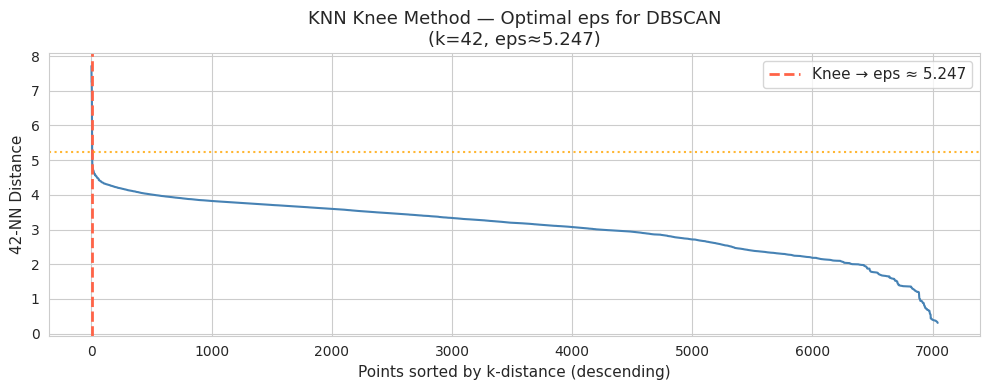


  → min_samples (ln rule): 8
  → Clusters found         : 1
  → Noise points           : 4 (0.1% of data)
  ⚠️  DBSCAN produced <2 meaningful clusters — try widening eps or decreasing min_samples.
  → Silhouette Score       : -1.0000
  → Adjusted Rand Index   : 0.0000


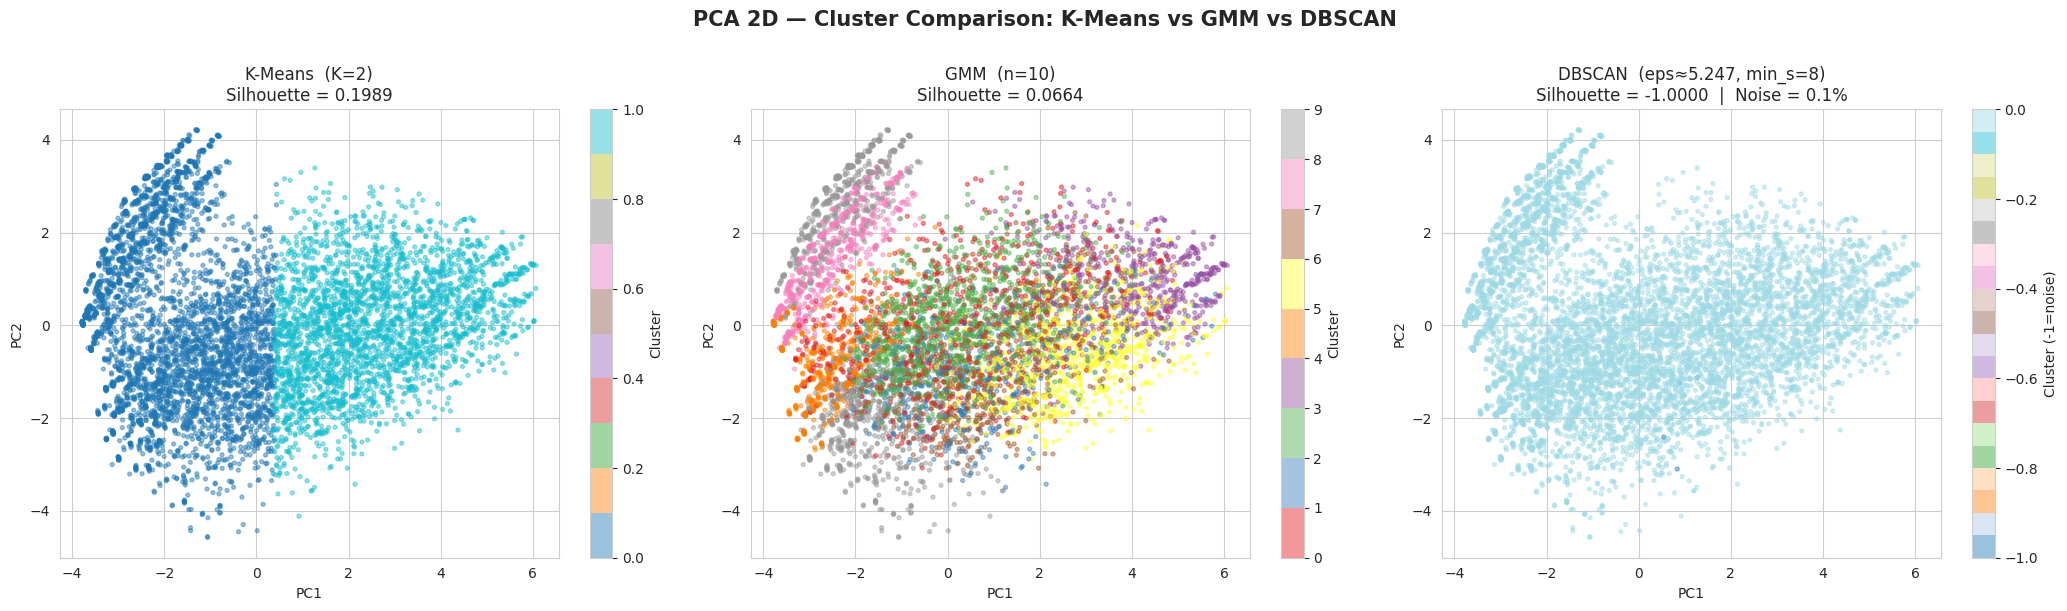

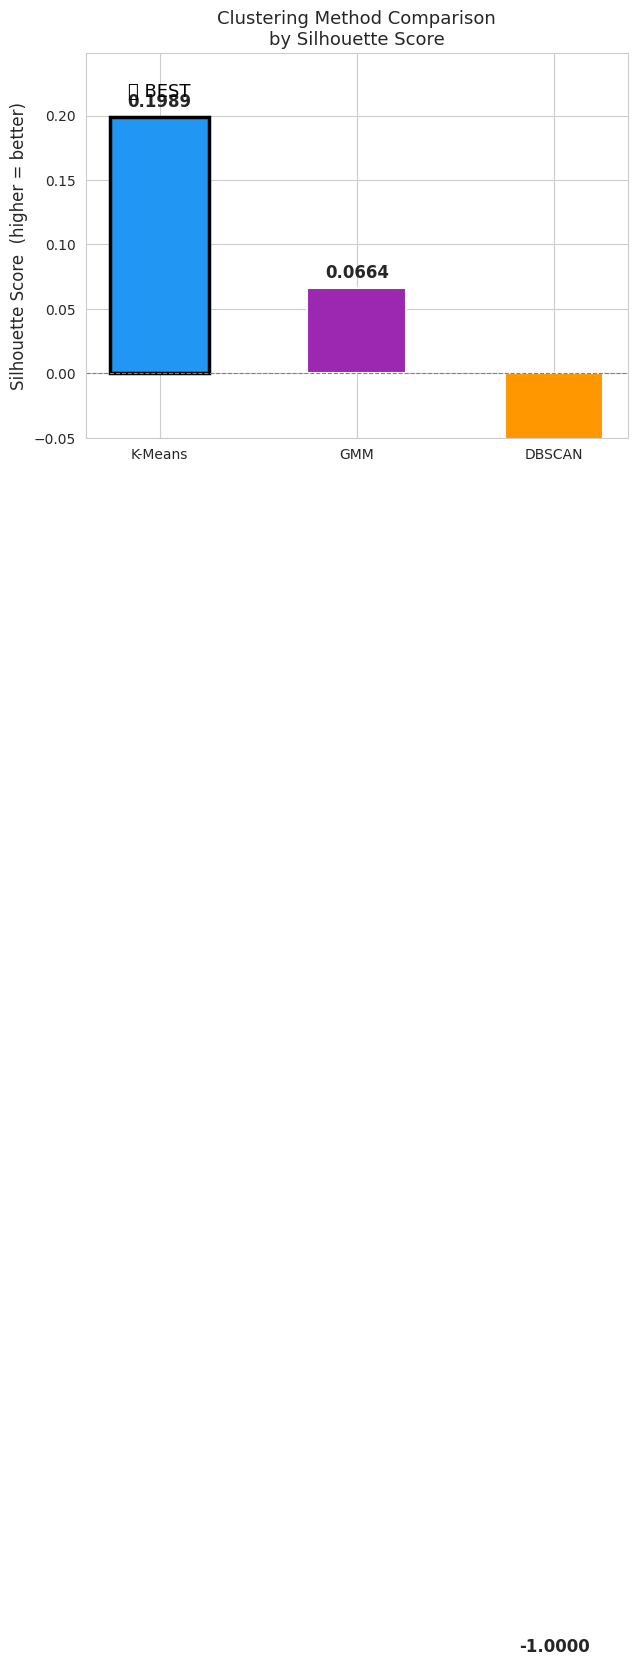


          CLUSTERING COMPARISON SUMMARY (UPGRADED)
Method                 Silhouette   ARI vs Churn   # Clusters
------------------------------------------------------------
K-Means                    0.1989        -0.0064            2 ◄ BEST
GMM                        0.0664         0.0213           10
DBSCAN                    -1.0000         0.0000            1

Interpretation Guide:
  Silhouette Score → closer to +1.0 = better cluster separation
  ARI              → closer to +1.0 = clusters align with true churn
  DBSCAN Noise     → points unassigned to any cluster

✅ Full upgraded pipeline complete!


In [23]:
# ── 3a. Auto-estimate eps via KNN Knee method ─────────────────────
print('─' * 50)
print('  DBSCAN: Estimating optimal eps via KNN Knee Method')
print('─' * 50)

# Use k = 2 * n_features as a robust default (common heuristic)
k_neighbors = max(2 * X_scaled.shape[1], 5)

nbrs = NearestNeighbors(n_neighbors=k_neighbors, algorithm='auto', n_jobs=-1)
nbrs.fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# k-distance = distance to the k-th nearest neighbor (last column)
k_distances = np.sort(distances[:, -1])[::-1]   # descending

# Knee detection: largest second-derivative point
diff1 = np.diff(k_distances)
diff2 = np.diff(diff1)
knee_idx = np.argmax(np.abs(diff2)) + 1          # +1 to offset double-diff
eps_auto = float(k_distances[knee_idx])
print(f'  → k used for KNN distance: {k_neighbors}')
print(f'  → Knee index             : {knee_idx}')
print(f'  → Auto-estimated eps     : {eps_auto:.4f}')

# Plot the k-distance graph
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(k_distances)), k_distances, color='steelblue', lw=1.5)
ax.axvline(x=knee_idx, color='tomato', linestyle='--', lw=2,
           label=f'Knee → eps ≈ {eps_auto:.3f}')
ax.axhline(y=eps_auto, color='orange', linestyle=':', lw=1.5, alpha=0.8)
ax.set_xlabel('Points sorted by k-distance (descending)', fontsize=11)
ax.set_ylabel(f'{k_neighbors}-NN Distance', fontsize=11)
ax.set_title(f'KNN Knee Method — Optimal eps for DBSCAN\n'
             f'(k={k_neighbors}, eps≈{eps_auto:.3f})', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('dbscan_knee_method.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3b. Fit DBSCAN with auto-estimated eps ────────────────────────
# min_samples: common rule-of-thumb = ln(n_samples) or 2*n_features
min_samples_auto = max(int(np.log(X_scaled.shape[0])), 5)
print(f'\n  → min_samples (ln rule): {min_samples_auto}')

dbscan = DBSCAN(eps=eps_auto, min_samples=min_samples_auto, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db  = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db     = np.sum(dbscan_labels == -1)
pct_noise      = 100 * n_noise_db / len(dbscan_labels)

print(f'  → Clusters found         : {n_clusters_db}')
print(f'  → Noise points           : {n_noise_db} ({pct_noise:.1f}% of data)')

# Silhouette requires ≥ 2 clusters and excludes noise label (-1)
mask_valid = dbscan_labels != -1
if n_clusters_db >= 2 and mask_valid.sum() > n_clusters_db:
    sil_dbscan = silhouette_score(X_scaled[mask_valid], dbscan_labels[mask_valid])
    ari_dbscan = adjusted_rand_score(y_true[mask_valid], dbscan_labels[mask_valid])
else:
    sil_dbscan = -1.0   # degenerate result
    ari_dbscan = 0.0
    print('  ⚠️  DBSCAN produced <2 meaningful clusters — '
          'try widening eps or decreasing min_samples.')

print(f'  → Silhouette Score       : {sil_dbscan:.4f}')
print(f'  → Adjusted Rand Index   : {ari_dbscan:.4f}')


# ── 3c. PCA 2D  — 3-panel: K-Means | GMM | DBSCAN ────────────────
# pca / X_pca already computed by existing Cell 33; reuse them.
# If running standalone, uncomment:
# pca   = PCA(n_components=2, random_state=42)
# X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('PCA 2D — Cluster Comparison: K-Means vs GMM vs DBSCAN',
             fontsize=15, fontweight='bold', y=1.01)

# Colour maps
cmap_km    = 'tab10'
cmap_gmm   = 'Set1'
cmap_db    = 'tab20'

# Panel 1 — K-Means
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=kmeans_labels, cmap=cmap_km,
                      alpha=0.45, s=8)
axes[0].set_title(f'K-Means  (K={best_k})\nSilhouette = {sil_km:.4f}',
                  fontsize=12)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

# Panel 2 — GMM
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=gmm_labels, cmap=cmap_gmm,
                      alpha=0.45, s=8)
axes[1].set_title(f'GMM  (n={best_n_gmm})\nSilhouette = {sil_gmm:.4f}',
                  fontsize=12)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

# Panel 3 — DBSCAN  (noise = grey)
colors_db = np.where(dbscan_labels == -1, -1, dbscan_labels)
sc3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=colors_db, cmap=cmap_db,
                      alpha=0.45, s=8)
axes[2].set_title(
    f'DBSCAN  (eps≈{eps_auto:.3f}, min_s={min_samples_auto})\n'
    f'Silhouette = {sil_dbscan:.4f}  |  Noise = {pct_noise:.1f}%',
    fontsize=12)
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
plt.colorbar(sc3, ax=axes[2], label='Cluster (-1=noise)')

plt.tight_layout()
plt.savefig('unsupervised_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3d. Silhouette Score bar chart ───────────────────────────────
methods      = ['K-Means', 'GMM', 'DBSCAN']
sil_scores   = [sil_km, sil_gmm, sil_dbscan]
bar_colors   = ['#2196F3', '#9C27B0', '#FF9800']

best_cluster_name = methods[np.argmax(sil_scores)]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(methods, sil_scores, color=bar_colors, edgecolor='white',
              linewidth=1.5, width=0.5)

# Highlight best bar
best_idx = np.argmax(sil_scores)
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(2.5)

for bar, score in zip(bars, sil_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=0, color='grey', lw=0.8, linestyle='--')
ax.set_ylim(-0.05, max(sil_scores) * 1.25)
ax.set_ylabel('Silhouette Score  (higher = better)', fontsize=12)
ax.set_title('Clustering Method Comparison\nby Silhouette Score', fontsize=13)
ax.text(best_idx, sil_scores[best_idx] + max(sil_scores) * 0.08,
        '🏆 BEST', ha='center', fontsize=13, color='black')
plt.tight_layout()
plt.savefig('clustering_silhouette_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3e. Unsupervised comparison table ────────────────────────────
print('\n' + '=' * 60)
print('          CLUSTERING COMPARISON SUMMARY (UPGRADED)')
print('=' * 60)
print(f'{"Method":<20} {"Silhouette":>12} {"ARI vs Churn":>14} {"# Clusters":>12}')
print('-' * 60)
cluster_details = {
    'K-Means' : (sil_km,     ari_km,     best_k),
    'GMM'     : (sil_gmm,    ari_gmm,    best_n_gmm),
    'DBSCAN'  : (sil_dbscan, ari_dbscan, n_clusters_db),
}
for name, (sil, ari, nc) in cluster_details.items():
    marker = ' ◄ BEST' if name == best_cluster_name else ''
    print(f'{name:<20} {sil:>12.4f} {ari:>14.4f} {nc:>12}{marker}')
print('=' * 60)

print('\nInterpretation Guide:')
print('  Silhouette Score → closer to +1.0 = better cluster separation')
print('  ARI              → closer to +1.0 = clusters align with true churn')
print('  DBSCAN Noise     → points unassigned to any cluster')
print()
print('✅ Full upgraded pipeline complete!')